# Import Libraries

In [37]:
#Basic import
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Modelling
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


##### Read the dataset

In [27]:
df = pd.read_csv('data/StudentsPerformance.csv')

#### Show top 5 Records

In [28]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing x and y variables

In [29]:
X = df.drop(columns=['math score'],axis=1)

In [30]:
Y = df['math score']

In [31]:
# Create column Transformer with 3 types of tramsformers
numeric_features = X.select_dtypes(exclude="object").columns
categorical_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_tramsformer = StandardScaler()
oh_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, categorical_features),
        ("StandardScaler", numeric_tramsformer, numeric_features),
    ]
)

In [32]:
X = preprocessor.fit_transform(X)

In [33]:
X.shape

(1000, 19)

In [34]:
#seperate train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an evaluate function to give all metrics after model training

In [35]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae,  rmse, r2_square

In [38]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(),
    "Ridge Regression": Ridge(),
    "KNeighbors Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, Y_train)

    #Make predictions
    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    #Evaluate Train nad Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(Y_train, Y_train_pred)

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(Y_test, Y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance on Training Set')
    print("Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    
    print('------------------------------------------------')

    print('Model performance on Test Set')
    print("Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')


Linear Regression
Model performance on Training Set
Root Mean Squared Error: 5.3231
Mean Absolute Error: 4.2667
- R2 Score: 0.8743
------------------------------------------------
Model performance on Test Set
Root Mean Squared Error: 5.3940
Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso Regression
Model performance on Training Set
Root Mean Squared Error: 6.5938
Mean Absolute Error: 5.2063
- R2 Score: 0.8071
------------------------------------------------
Model performance on Test Set
Root Mean Squared Error: 6.5197
Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge Regression
Model performance on Training Set
Root Mean Squared Error: 5.3233
Mean Absolute Error: 4.2650
- R2 Score: 0.8743
------------------------------------------------
Model performance on Test Set
Root Mean Squared Error: 5.3904
Mean Absolute Error: 4.2111
- R2 Score: 0.8806


KNeighbors Regressor
Model performance on Training Set
Root Mean Squared Error: 5.7079
Mean Absolute Error: 4.5168
- R2 Score: 0.

In [41]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by = ["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge Regression,0.880593
0,Linear Regression,0.880433
8,AdaBoost Regressor,0.853923
7,CatBoost Regressor,0.851632
5,Random Forest Regressor,0.851471
6,XGBRegressor,0.827797
1,Lasso Regression,0.825320
3,KNeighbors Regressor,0.783813
4,Decision Tree Regressor,0.743505


##### Linear Regression

In [42]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, Y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(Y_test, y_pred)*100
print("Accuracy of Linear Regression Model is: %.2f" %score)

Accuracy of Linear Regression Model is: 88.04


##### Plot y_pred and y_test

Text(0, 0.5, 'Predicted Values')

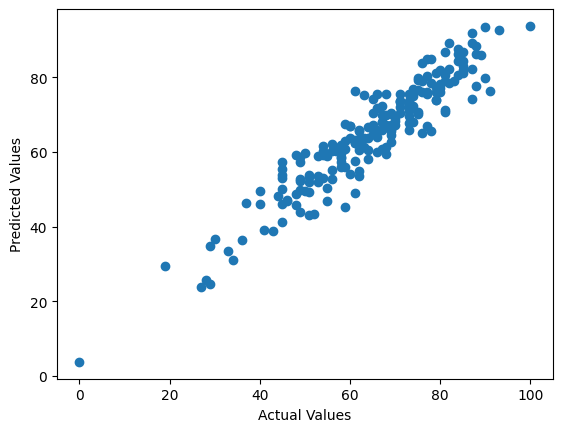

In [43]:
plt.scatter(Y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

<Axes: xlabel='math score'>

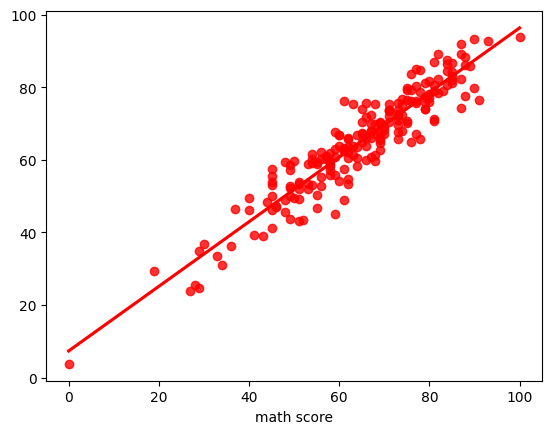

In [44]:
sns.regplot(x=Y_test, y=y_pred, ci=None, color ='red')

##### Difference between Actual v/s Predicted Values

In [45]:
pred_df = pd.DataFrame({'Actual Values': Y_test, 'Predicted Values': y_pred, 'Difference': Y_test - y_pred})
pred_df

,Actual Values,Predicted Values,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
